Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

print(' Libraries imported!')

 Libraries imported!


Data Load

In [2]:
path = r'C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed'

X_train = pd.read_csv(f'{path}\\X_train_tabular.csv')
X_test  = pd.read_csv(f'{path}\\X_test_tabular.csv')
y_train = pd.read_csv(f'{path}\\y_train_tabular.csv').squeeze()
y_test  = pd.read_csv(f'{path}\\y_test_tabular.csv').squeeze()

print(' Data loaded!')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')

 Data loaded!
X_train shape: (1719, 32)
X_test shape : (430, 32)


XGBoost Train

In [3]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=2,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
print(' XGBoost trained!')

 XGBoost trained!


SHAP Values

In [4]:
print('Calculating SHAP values...')

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(' SHAP values calculated!')
print(f'Shape: {shap_values.shape}')

Calculating SHAP values...
 SHAP values calculated!
Shape: (430, 32)


Bar Plot

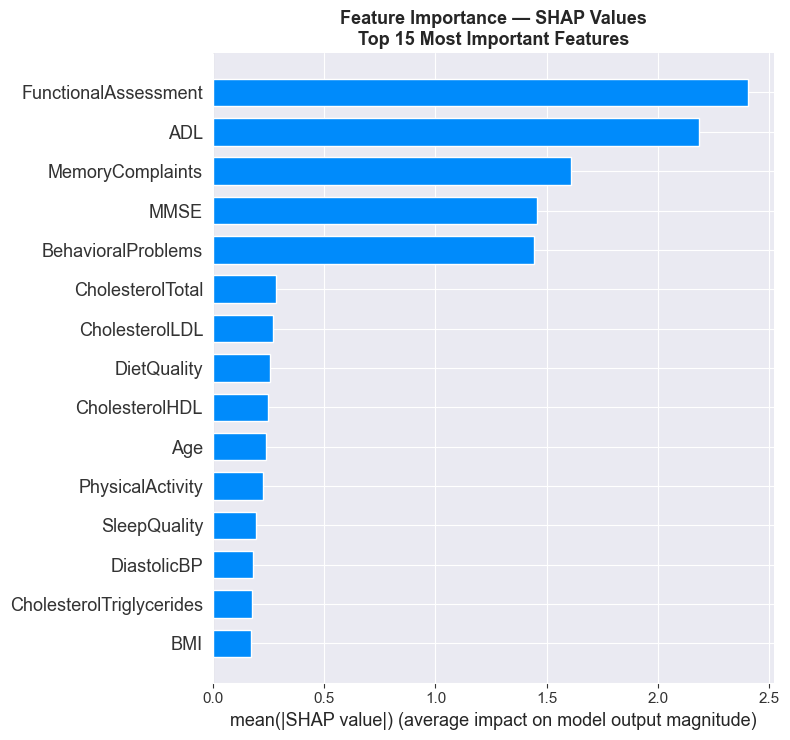

 SHAP bar plot saved!


In [5]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',
    max_display=15,
    show=False
)

plt.title(
    'Feature Importance — SHAP Values\n'
    'Top 15 Most Important Features',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('shap_bar.png',
            dpi=150,
            bbox_inches='tight')
plt.show()
print(' SHAP bar plot saved!')

Dot Plot

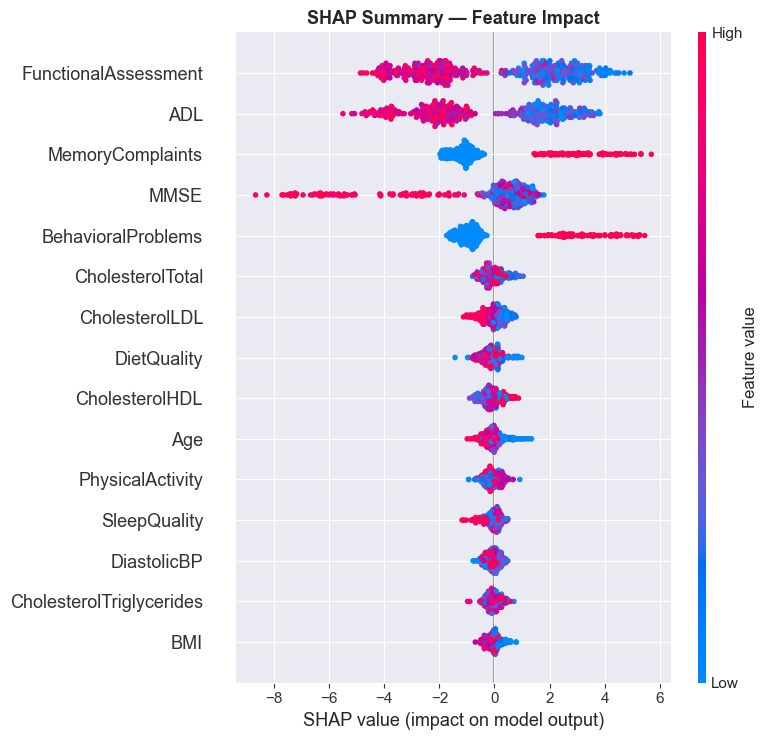

 SHAP dot plot saved!


In [6]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test,
    max_display=15,
    show=False
)

plt.title(
    'SHAP Summary — Feature Impact',
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('shap_dot.png',
            dpi=150,
            bbox_inches='tight')
plt.show()
print(' SHAP dot plot saved!')

Top Features Table

In [7]:
feature_importance = pd.DataFrame({
    'Feature'   : X_test.columns,
    'SHAP_Value': np.abs(shap_values).mean(0)
})

feature_importance = feature_importance.sort_values(
    'SHAP_Value',
    ascending=False
).reset_index(drop=True)

print(' Top 10 Most Important Features:')
print('=' * 45)
print(feature_importance.head(10).to_string(
    index=False
))
print('=' * 45)

# Save
feature_importance.to_csv(
    f'{path}\\shap_feature_importance.csv',
    index=False
)
print('\n SHAP Analysis Complete!')
print('Next → Streamlit Dashboard!')

 Top 10 Most Important Features:
             Feature  SHAP_Value
FunctionalAssessment    2.401453
                 ADL    2.182567
    MemoryComplaints    1.607556
                MMSE    1.455194
  BehavioralProblems    1.440453
    CholesterolTotal    0.282632
      CholesterolLDL    0.270836
         DietQuality    0.255616
      CholesterolHDL    0.246726
                 Age    0.238858

 SHAP Analysis Complete!
Next → Streamlit Dashboard!
